## Imports


In [1]:
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    brier_score_loss,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

## Configuration


In [2]:
RANDOM_STATE = 42
STORAGE_PATH = Path("../../mock-cloud/storage")
DATASET_PATH = STORAGE_PATH / "data" / "processed" / "employee_attrition_encoded.parquet"
MODEL_ARTIFACT_PATH = STORAGE_PATH / "models" / "attrition_classifier_artifact.joblib"

In [3]:
plt.style.use("seaborn-v0_8")
sns.set_theme(palette="deep")
pd.options.display.float_format = "{:.4f}".format

## Load Encoded Dataset


In [4]:
df = pd.read_parquet(DATASET_PATH)
df.head()

,Department,Salary,ActiveProjects,AvgMonthlyHours,YearsAtCompany,WorkAccidents,ReceivedPromotion,LastEvaluation,SatisfactionScore,Attrition
0,sales,0.0000,2,157,3,0,0,0.5300,0.3800,1
1,sales,0.5000,5,262,6,0,0,0.8600,0.8000,1
2,sales,0.5000,7,272,4,0,0,0.8800,0.1100,1
3,sales,0.0000,5,223,5,0,0,0.8700,0.7200,1
4,sales,0.0000,2,159,3,0,0,0.5200,0.3700,1


In [5]:
X = df.drop(columns="Attrition")
y = df.Attrition

pd.Series({
    "rows": len(df),
    "features": X.shape[1],
    "target_positive_rate": y.mean(),
})

rows                   14999.0000
features                   9.0000
target_positive_rate       0.2381
dtype: float64

## Train / Test Split


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "positive_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

,rows,positive_rate
train,11999,0.2381
test,3000,0.2380


## Preprocessing


In [7]:
categorical_features = ["Department"]
numeric_features = [column for column in X.columns if column not in categorical_features]

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features
        ),
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
            ]),
            numeric_features
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features
        ),
        ("numeric", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
    ],
    sparse_threshold=0,
)

## Risk Scoring Helpers


In [8]:
SALARY_LABELS: dict[float, str] = {0: "low", 0.5: "medium", 1: "high"}


def predict_attrition_risk(pipeline: Any, features: pd.DataFrame) -> pd.Series:
    risk = pipeline.predict_proba(features)[:, 1]
    return pd.Series(risk, index=features.index, name="attrition_risk")


def build_scenario_table(pipeline: Any, baseline_row: pd.Series) -> pd.DataFrame:
    scenarios = [
        ("Baseline profile", {}),
        ("Higher satisfaction", {"SatisfactionScore": min(1.0, baseline_row["SatisfactionScore"] + 0.25)}),
        ("Promotion received", {"ReceivedPromotion": 1}),
        ("Higher salary tier", {"Salary": min(2, int(baseline_row["Salary"]) + 1)}),
        ("Lighter workload", {"ActiveProjects": max(2, int(baseline_row["ActiveProjects"]) - 1)}),
        ("Longer hours", {"AvgMonthlyHours": int(baseline_row["AvgMonthlyHours"]) + 30}),
    ]

    rows: list[dict] = []
    baseline_risk: float | None = None

    for scenario_name, updates in scenarios:
        row = baseline_row.copy()
        for key, value in updates.items():
            row[key] = value

        scenario_df = pd.DataFrame([row])
        risk = float(predict_attrition_risk(pipeline, scenario_df).iloc[0])

        if baseline_risk is None:
            baseline_risk = risk

        rows.append({
            "scenario": scenario_name,
            "attrition_risk": round(risk, 4),
            "delta_risk": round(risk - baseline_risk, 4),
            "salary_label": SALARY_LABELS.get(int(row["Salary"]), str(row["Salary"])),
            "active_projects": int(row["ActiveProjects"]),
            "avg_monthly_hours": int(row["AvgMonthlyHours"]),
            "received_promotion": int(row["ReceivedPromotion"]),
            "satisfaction_score": round(float(row["SatisfactionScore"]), 2),
        })

    return pd.DataFrame(rows)

## Base Model Configurations


In [9]:
model_specs = {
    "dummy_baseline": {
        "family": "baseline",
        "pipeline": Pipeline([
            ("preprocess", clone(tree_preprocessor)),
            ("model", DummyClassifier(
                strategy="stratified",
                random_state=RANDOM_STATE
            )),
        ]),
    },
    "logistic_regression": {
        "family": "linear",
        "pipeline": Pipeline([
            ("preprocess", clone(linear_preprocessor)),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )),
        ]),
    },
    "decision_tree": {
        "family": "tree",
        "pipeline": Pipeline([
            ("preprocess", clone(tree_preprocessor)),
            ("model", DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=50,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
    },
    "random_forest": {
        "family": "ensemble",
        "pipeline": Pipeline([
            ("preprocess", clone(tree_preprocessor)),
            ("model", RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=10,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
    },
    "hist_gradient_boosting": {
        "family": "ensemble",
        "pipeline": Pipeline([
            ("preprocess", clone(tree_preprocessor)),
            ("model", HistGradientBoostingClassifier(
                max_depth=8,
                learning_rate=0.05,
                max_iter=300,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
    },
    "stacked_ensemble": {
        "family": "stacking",
        "pipeline": Pipeline([
            ("model", StackingClassifier(
                estimators=[
                    ("lr", Pipeline([
                        ("preprocess", clone(linear_preprocessor)),
                        ("model", LogisticRegression(
                            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
                        )),
                    ])),
                    ("rf", Pipeline([
                        ("preprocess", clone(tree_preprocessor)),
                        ("model", RandomForestClassifier(
                            n_estimators=200, min_samples_leaf=10, class_weight="balanced_subsample",
                            random_state=RANDOM_STATE, n_jobs=-1
                        )),
                    ])),
                    ("hgb", Pipeline([
                        ("preprocess", clone(tree_preprocessor)),
                        ("model", HistGradientBoostingClassifier(
                            max_depth=8, learning_rate=0.05, max_iter=300, min_samples_leaf=20,
                            class_weight="balanced", random_state=RANDOM_STATE
                        )),
                    ])),
                ],
                final_estimator=LogisticRegression(
                    max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
                ),
                cv=5,
                stack_method="predict_proba",
                n_jobs=-1,
            )),
        ]),
    },
}

## Base Model Cross-Validation


In [10]:
cv_models = []
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision", # because we use proba output, not binary
    "recall": "recall",
    "f1": "f1",
    "neg_brier_score": "neg_brier_score",
}

for model_name, spec in model_specs.items():
    scores = cross_validate(
        spec["pipeline"],
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=False,
    )

    row = {
        "model": model_name,
        "family": spec["family"],
    }

    for metric in scoring:
        row[f"{metric}"] = scores[f"test_{metric}"].mean()

    cv_models.append(row)

cv_result = pd.DataFrame(cv_models).sort_values("recall", ascending=False).reset_index(drop=True)
cv_result

,model,family,roc_auc,avg_precision,recall,f1,neg_brier_score
0,stacked_ensemble,stacking,0.9924,0.9876,0.9674,0.9669,-0.0143
1,hist_gradient_boosting,ensemble,0.9920,0.9874,0.9650,0.9692,-0.0133
2,decision_tree,tree,0.9630,0.8739,0.9331,0.8719,-0.0582
3,random_forest,ensemble,0.9901,0.9813,0.9156,0.9457,-0.0233
4,logistic_regression,linear,0.8252,0.4867,0.7963,0.6086,-0.1752
5,dummy_baseline,baseline,0.4967,0.2370,0.2324,0.2327,-0.3649


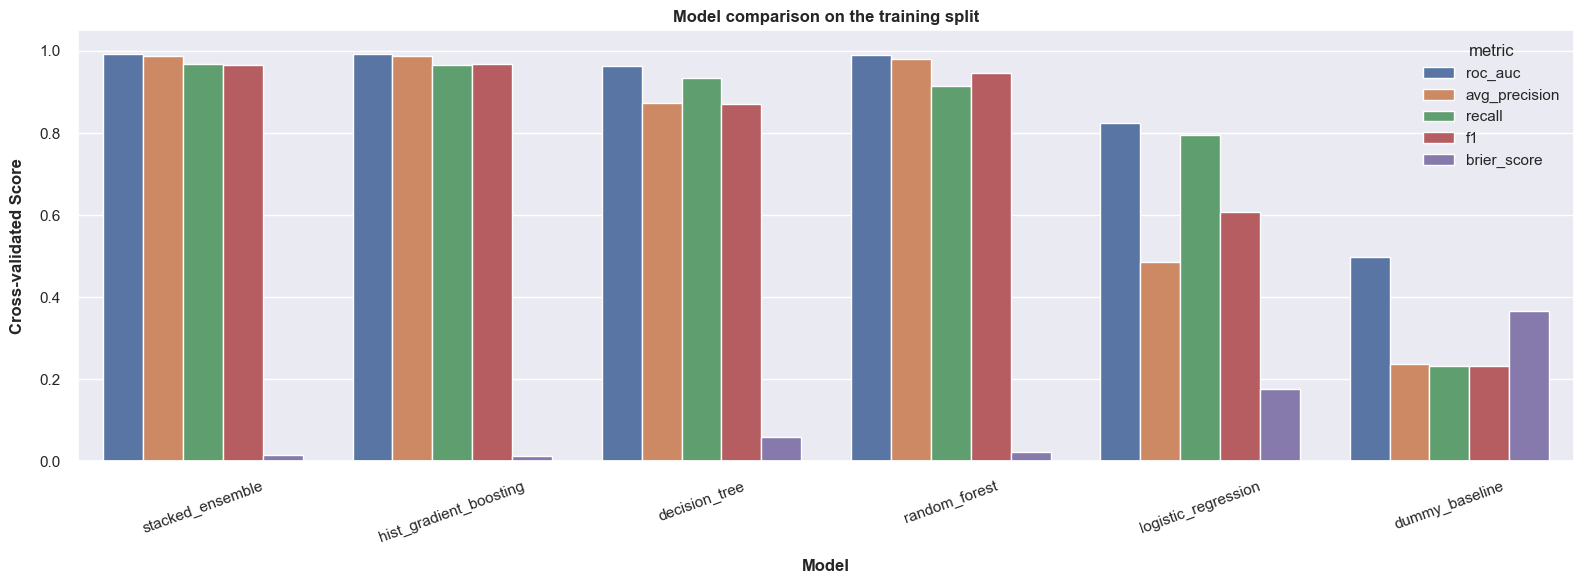

In [11]:
plot_data = cv_result[[
    "model", "roc_auc", "avg_precision", 
    "recall", "f1", "neg_brier_score",
]]
plot_data = plot_data.melt(id_vars="model", var_name="metric", value_name="score")
plot_data.loc[plot_data["metric"] == "neg_brier_score", "score"] *= -1
plot_data.loc[plot_data["metric"] == "neg_brier_score", "metric"] = "brier_score"
plot_data["metric"] = plot_data["metric"].str.replace("_mean$", "", regex=True)

plt.figure(figsize=(16, 6))
sns.barplot(data=plot_data, x="model", y="score", hue="metric")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.xlabel("Model", fontweight="bold", labelpad=10)
plt.ylabel("Cross-validated Score", fontweight="bold", labelpad=10)
plt.title("Model comparison on the training split", fontweight="bold")
plt.tight_layout()
plt.show()

## Risk Evaluation and Model Selection


In [12]:
test_rows = []
fitted_models = {}

for model_name, spec in model_specs.items():
    pipeline = spec["pipeline"]
    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline

    y_score = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    test_rows.append({
        "model": model_name,
        "family": spec["family"],
        "roc_auc": roc_auc_score(y_test, y_score),
        "avg_precision": average_precision_score(y_test, y_score),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "brier_score": brier_score_loss(y_test, y_score),
        "avg_risk_retained": y_score[y_test == 0].mean(),
        "avg_risk_attrited": y_score[y_test == 1].mean(),
    })

test_results = pd.DataFrame(test_rows).sort_values("recall", ascending=False).reset_index(drop=True)
test_results

,model,family,roc_auc,avg_precision,recall,f1,brier_score,avg_risk_retained,avg_risk_attrited
0,stacked_ensemble,stacking,0.9937,0.9901,0.9692,0.9645,0.0147,0.0376,0.9654
1,hist_gradient_boosting,ensemble,0.9947,0.9902,0.9678,0.9678,0.0142,0.0322,0.9579
2,decision_tree,tree,0.9611,0.8382,0.9440,0.8736,0.0598,0.1090,0.8976
3,random_forest,ensemble,0.9903,0.9852,0.9202,0.9494,0.0217,0.0734,0.9147
4,logistic_regression,linear,0.8339,0.5034,0.7983,0.6226,0.1689,0.3309,0.6581
5,dummy_baseline,baseline,0.5018,0.2386,0.2437,0.2422,0.3630,0.2402,0.2437


In [13]:
# The choice falls on Gradient Boosting, since performance is as good as the stacked model, but it's less complex
best_model_name = test_results.loc[1, "model"]
best_model = fitted_models[best_model_name]

best_score = best_model.predict_proba(X_test)[:, 1]

## Calibration

A model with high ROC-AUC can still be poorly calibrated. Calibration ensures that when the model outputs 0.80, roughly 80 out of 100 comparable employees will actually leave. We wrap the best base model in an isotonic-regression calibrator using cross-validated out-of-fold predictions, then verify alignment with a reliability diagram.

In [14]:
calibrated_model = CalibratedClassifierCV(best_model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colu

In [15]:
cal_score = calibrated_model.predict_proba(X_test)[:, 1]

pd.DataFrame([
    {
        "model": "uncalibrated",
        "roc_auc": roc_auc_score(y_test, best_score),
        "avg_precision": average_precision_score(y_test, best_score),
        "brier_score": brier_score_loss(y_test, best_score),
    },
    {
        "model": "calibrated",
        "roc_auc": roc_auc_score(y_test, cal_score),
        "avg_precision": average_precision_score(y_test, cal_score),
        "brier_score": brier_score_loss(y_test, cal_score),
    },
])

,model,roc_auc,avg_precision,brier_score
0,uncalibrated,0.9947,0.9902,0.0142
1,calibrated,0.9944,0.9900,0.0119


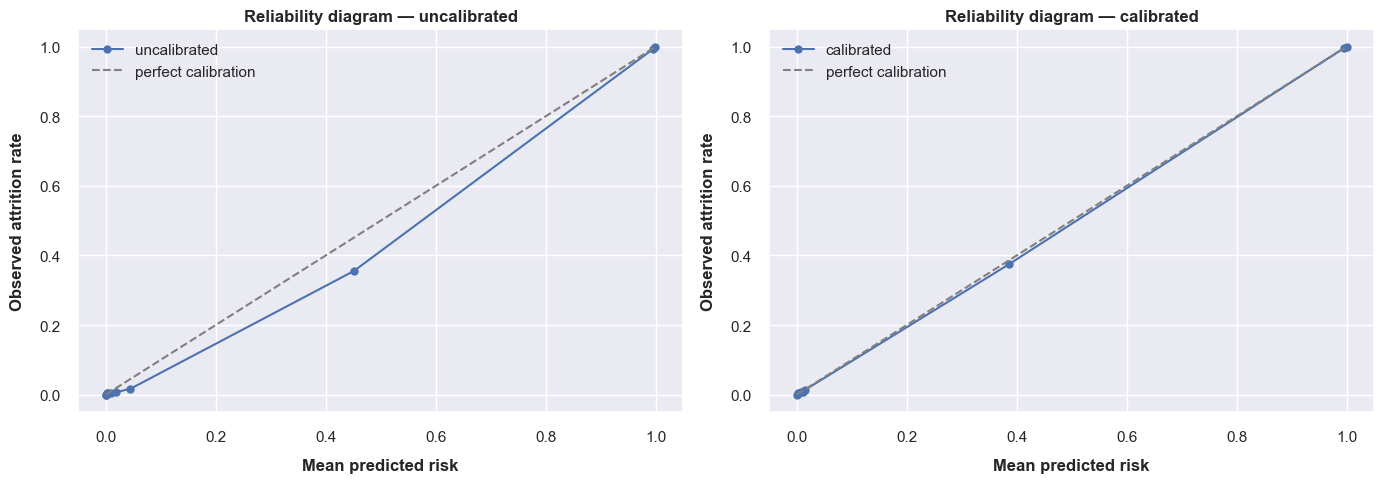

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, scores, ax in [
    ("uncalibrated", best_score, axes[0]),
    ("calibrated", cal_score, axes[1]),
]:
    frac_pos, mean_pred = calibration_curve(y_test, scores, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
    ax.set_xlabel("Mean predicted risk", fontweight="bold", labelpad=10)
    ax.set_ylabel("Observed attrition rate", fontweight="bold", labelpad=10)
    ax.set_title(f"Reliability diagram — {label}", fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.show()

## Interpret The Best (Calibrated) Model


In [17]:
perm = permutation_importance(
    calibrated_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": (perm.importances_mean * 100).round(2),
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
8,SatisfactionScore,19.8600
4,YearsAtCompany,7.1600
2,ActiveProjects,4.2200
3,AvgMonthlyHours,2.9800
7,LastEvaluation,2.1500
1,Salary,0.0800
0,Department,0.0600
5,WorkAccidents,0.0400
6,ReceivedPromotion,0.0100


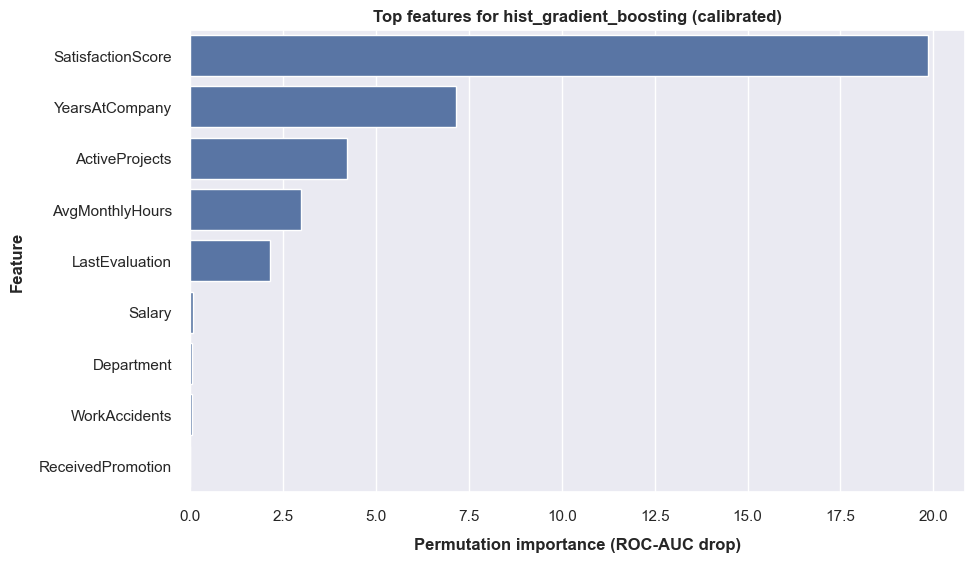

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.xlabel("Permutation importance (ROC-AUC drop)", fontweight="bold", labelpad=10)
plt.ylabel("Feature", fontweight="bold", labelpad=10)
plt.title(f"Top features for {best_model_name} (calibrated)", fontweight="bold")
plt.show()

## What-If Feature Changes


In [19]:
baseline_profile = X_train.median(numeric_only=True)
baseline_profile["Department"] = X_train["Department"].mode().iloc[0]
baseline_profile = baseline_profile[X.columns]

scenario_table = build_scenario_table(calibrated_model, baseline_profile)
scenario_table

,scenario,attrition_risk,delta_risk,salary_label,active_projects,avg_monthly_hours,received_promotion,satisfaction_score
0,Baseline profile,0.0061,0.0000,low,4,200,0,0.6400
1,Higher satisfaction,0.0036,-0.0024,low,4,200,0,0.8900
2,Promotion received,0.0029,-0.0032,low,4,200,1,0.6400
3,Higher salary tier,0.0016,-0.0045,high,4,200,0,0.6400
4,Lighter workload,0.0059,-0.0002,low,3,200,0,0.6400
5,Longer hours,0.0106,0.0046,low,4,230,0,0.6400


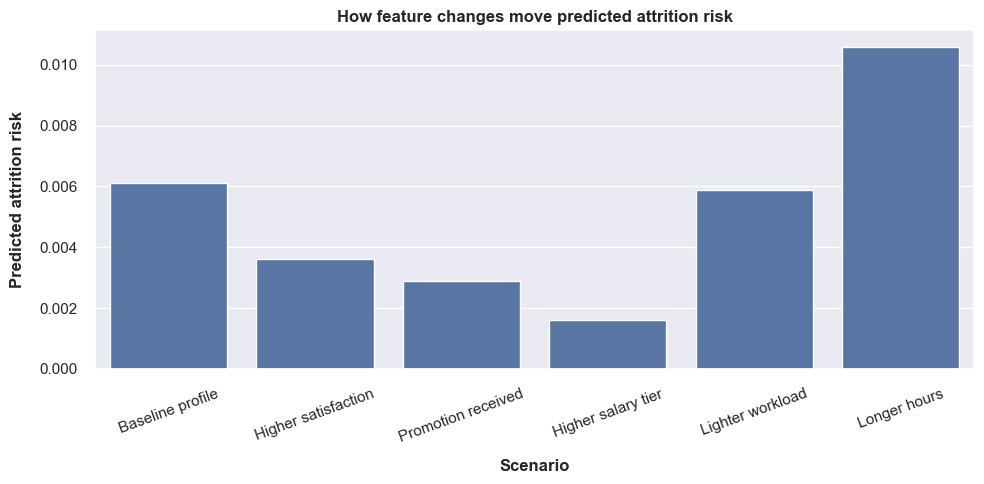

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=scenario_table, x="scenario", y="attrition_risk")
plt.xticks(rotation=20)
plt.xlabel("Scenario", fontweight="bold", labelpad=10)
plt.ylabel("Predicted attrition risk", fontweight="bold", labelpad=10)
plt.title("How feature changes move predicted attrition risk", fontweight="bold")
plt.tight_layout()
plt.show()

## Winning Pipeline


In [21]:
MODEL_ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(calibrated_model, MODEL_ARTIFACT_PATH)

pd.Series({
    "saved_model": f"{best_model_name}",
    "calibrated": True,
    "test_roc_auc": roc_auc_score(y_test, cal_score),
    "test_average_precision": average_precision_score(y_test, cal_score),
    "test_brier_score": brier_score_loss(y_test, cal_score),
    "artifact_path": str(MODEL_ARTIFACT_PATH.resolve()),
})

saved_model                                          hist_gradient_boosting
calibrated                                                             True
test_roc_auc                                                         0.9944
test_average_precision                                               0.9900
test_brier_score                                                     0.0119
artifact_path             /Users/rmei/repos/hr-hub/mock-cloud/storage/mo...
dtype: object

## Modeling Takeaways

- A dummy stratified baseline performs poorly, so the features do contain real predictive signal.
- Logistic regression is useful as a linear benchmark, but it underfits the dataset relative to tree-based methods (since we established at EDA that linear signals are weak at best).
- A shallow decision tree captures some nonlinear behavior, but ensemble methods are clearly stronger.
- Histogram gradient boosting edges out random forest on probability-focused metrics, making it the best default artifact for backend use (among others, it has significantly better recall). Stacking model performed almost identically, so it does not justify the significant extra overhead.
- The model should be consumed as `attrition_risk` on a 0 to 1 scale, not only as a binary leave/stay label.
- The scenario table provides a simple way to see how feature changes move predicted likelihood up or down on that probability scale.
- The exported artifact is a calibrated estimator. Predicted `attrition_risk` can be interpreted as a probability: a score of 0.72 means approximately 72% probability of attrition, not only a relative ranking.

### Next

- The model already provide excellent results, scoring 96-99% across all metrics. Further hyperparameter tuning could be explored with GridSearchCV, but likely what is needed for better performance is more training data (synthetic?) and more examples from the imbalanced class.